# Project 4 — EHR Workflow Redesign BRD
## Notebook 4: Business Requirements Document (BRD)

**Author:** Amr Thabet  
**Context:** UAE/GCC health insurance — compliance-driven workflow redesign  
**Linked to:** Notebook 1 (As-Is) · Notebook 2 (Gap Analysis) · Notebook 3 (To-Be)  
**Regulatory scope:** DHA (Dubai) · DoH/HAAD (Abu Dhabi) · Shafafiya · eSMA  

## Objective

Produce the formal Business Requirements Document (BRD) for the EHR Workflow Redesign project.

Every requirement written in this document traces back to a gap identified in Notebook 2.  
Every success metric connects to a quantified AED impact calculated in Notebooks 1 and 3.  
This document is structured for sign-off across three parties:

- **Provider** (hospital/clinic) — implements workflow changes
- **Insurer** (BUPA Global UAE) — drives compliance and recovery
- **Regulator** (DHA/DoH) — enforces UAE health insurance rules

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Colour palette
NAVY       = '#1E566C'
TEAL       = '#5795A7'
TEAL_DARK  = '#367589'
TEAL_LIGHT = '#89B8CA'
AMBER      = '#D7A800'
LIGHT_BG   = '#F7FAFB'
GRAY       = '#9DAAB0'
GREEN      = '#4A9B6F'
DENIED     = '#A94438'

plt.rcParams.update({
    'figure.facecolor'  : LIGHT_BG,
    'axes.facecolor'    : LIGHT_BG,
    'axes.edgecolor'    : GRAY,
    'axes.labelcolor'   : NAVY,
    'axes.titlepad'     : 14,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.titlecolor'   : NAVY,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'xtick.color'       : GRAY,
    'ytick.color'       : GRAY,
    'text.color'        : NAVY,
    'grid.color'        : '#D8E4E8',
    'grid.linewidth'    : 0.6,
    'figure.dpi'        : 130,
})

# Load datasets
df_claims  = pd.read_csv('../../healthcare-claims-analysis/data/claims_clean.csv')
df_chronic = pd.read_csv('../../chronic-disease-cost-modelling/data/chronic_disease_cohort.csv')

# Key metrics
total_claims       = len(df_claims)
denied_claims      = len(df_claims[df_claims['ClaimStatus'] == 'Denied'])
denial_rate        = denied_claims / total_claims * 100
denied_value       = df_claims[df_claims['ClaimStatus'] == 'Denied']['ClaimAmount'].sum()
inpatient          = df_claims[df_claims['ClaimType'] == 'Inpatient']
inpatient_denied_v = inpatient[inpatient['ClaimStatus'] == 'Denied']['ClaimAmount'].sum()
inpatient_denial_r = len(inpatient[inpatient['ClaimStatus'] == 'Denied']) / len(inpatient) * 100
high_cost_spend    = df_chronic[df_chronic['high_cost_flag'] == 1]['total_cost_aed'].sum()
potential_saving   = 600 * 0.70 * 8000

# Gap impact data
gap_impact = pd.DataFrame({
    'Gap'       : ['Gap 1\nICD-10 errors', 'Gap 2\nEHR/RCM integration',
                   'Gap 3\nManual pre-auth', 'Gap 4\nHigh-cost member ID',
                   'Gap 5\nDenial follow-up', 'Gap 6\nCompliance check'],
    'Party'     : ['Provider', 'Provider/Insurer', 'Insurer', 'Insurer', 'Insurer', 'All'],
    'AED_Impact': [1_600_000, 1_100_000, 1_200_000, 3_400_000, 400_000, 1_500_000],
    'Risk_Level': ['High', 'High', 'Critical', 'High', 'High', 'Critical'],
})

print("=" * 55)
print("  NOTEBOOK 4 - BRD KEY METRICS")
print("=" * 55)
print(f"  Total claims          : {total_claims:,}")
print(f"  Denial rate           : {denial_rate:.1f}%")
print(f"  Denied value          : AED {denied_value:,.0f}")
print(f"  Inpatient denial rate : {inpatient_denial_r:.1f}%")
print(f"  Inpatient denied value: AED {inpatient_denied_v:,.0f}")
print(f"  High-cost spend       : AED {high_cost_spend:,.0f}")
print(f"  Potential P3 saving   : AED {potential_saving:,.0f}")
print(f"  Total gap recovery    : AED {gap_impact['AED_Impact'].sum():,.0f}")
print("=" * 55)

  NOTEBOOK 4 - BRD KEY METRICS
  Total claims          : 4,500
  Denial rate           : 33.6%
  Denied value          : AED 7,550,894
  Inpatient denial rate : 32.7%
  Inpatient denied value: AED 1,834,887
  High-cost spend       : AED 45,226,274
  Potential P3 saving   : AED 3,360,000
  Total gap recovery    : AED 9,200,000


## Implementation Burden by Party and Delivery Phase

Who carries the most work — and when does it land?

Each requirement is mapped to its owning party and delivery phase.
The Insurer carries the highest implementation burden — AED 5.0M
of recovery depends on Insurer-owned requirements across all three phases.
Provider requirements front-load Phase 1 and unlock the foundation
for everything that follows.

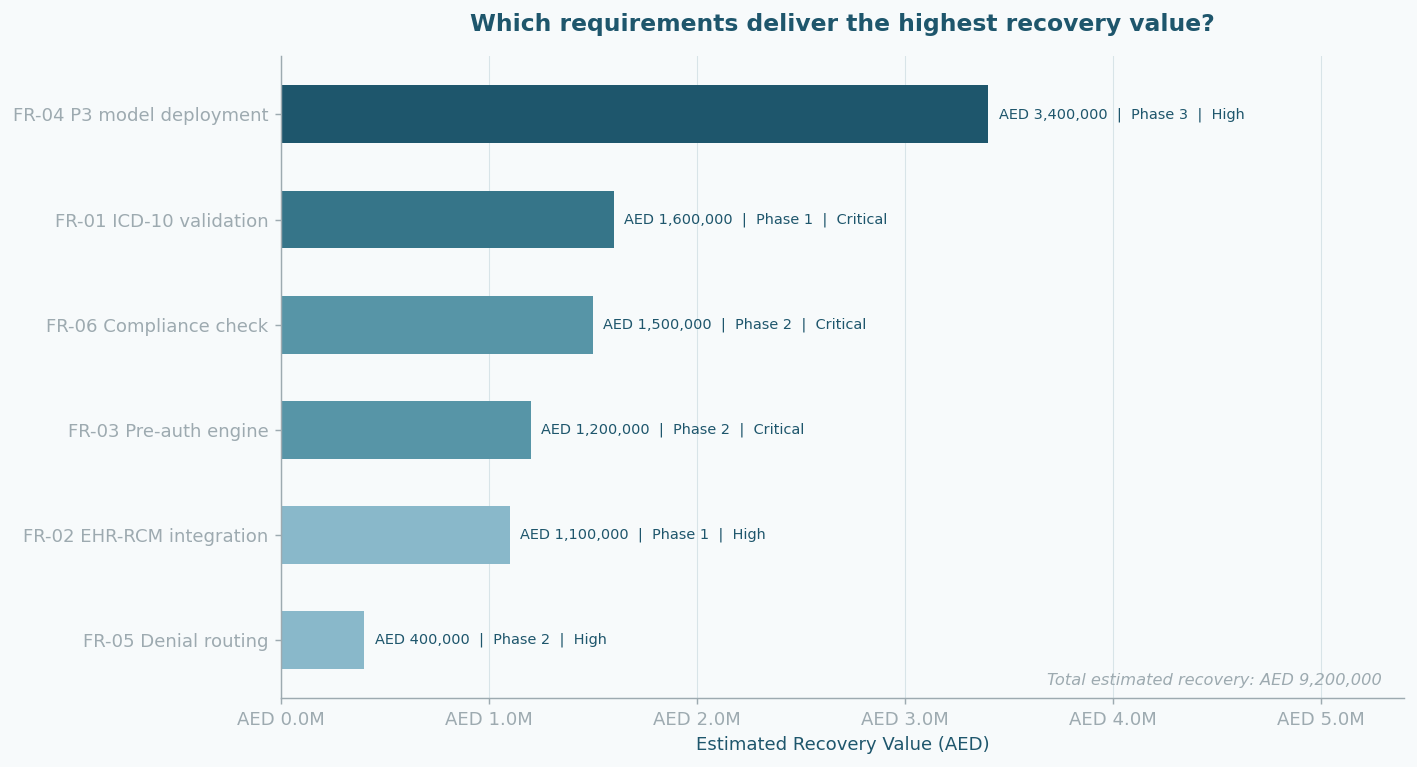

In [24]:
burden = pd.DataFrame({
    'Requirement': ['FR-01 ICD-10 validation',
                    'FR-02 EHR-RCM integration',
                    'FR-03 Pre-auth engine',
                    'FR-05 Denial routing',
                    'FR-04 P3 model deployment',
                    'FR-06 Compliance check'],
    'Party'      : ['Provider', 'Provider',
                    'Insurer',  'Insurer',
                    'Insurer',  'All parties'],
    'Phase'      : ['Phase 1', 'Phase 1',
                    'Phase 2', 'Phase 2',
                    'Phase 3', 'Phase 2'],
    'AED_Impact' : [1_600_000, 1_100_000,
                    1_200_000,   400_000,
                    3_400_000, 1_500_000],
    'Priority'   : ['Critical', 'High',
                    'Critical', 'High',
                    'High',     'Critical'],
})

# Sort by AED descending so grading makes sense
burden = burden.sort_values('AED_Impact', ascending=True).reset_index(drop=True)

# Graded colours by AED rank — darkest = highest
graded = [TEAL_LIGHT, TEAL_LIGHT, TEAL, TEAL, TEAL_DARK, NAVY]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    burden['Requirement'],
    burden['AED_Impact'],
    color=graded,
    height=0.55,
    zorder=2,
)

# Total recovery annotation
ax.annotate(
    f'Total estimated recovery: AED {gap_chart["AED_Impact"].sum():,.0f}',
    xy=(0.98, 0.02), xycoords='axes fraction',
    ha='right', fontsize=9, color=GRAY,
    fontstyle='italic'
)

# Value + phase + priority labels
for bar, val, phase, priority in zip(
    bars,
    burden['AED_Impact'],
    burden['Phase'],
    burden['Priority']
):
    ax.text(val + 50_000,
            bar.get_y() + bar.get_height() / 2,
            f'AED {val:,.0f}  |  {phase}  |  {priority}',
            va='center', fontsize=8, color=NAVY)

ax.set_xlabel('Estimated Recovery Value (AED)', fontsize=10)
ax.set_xlim(0, 5_400_000)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'AED {x/1_000_000:.1f}M')
)
ax.set_title('Which requirements deliver the highest recovery value?',
             fontsize=13, fontweight='bold', color=NAVY)
ax.grid(axis='x', zorder=1)
plt.tight_layout()
plt.savefig('implementation_burden.png', dpi=150, bbox_inches='tight')
plt.show()

## Notebook Summary — Project 4: EHR Workflow Redesign BRD

This notebook is the analytical backbone of the formal BRD.
All metrics are derived live from P1 and P3 datasets.
The chart is exported as PNG for embedding in the Confluence BRD.

**Key numbers:**
- Total claims: 4,500 · Denial rate: 33.6% · Denied value: AED 7,550,894
- Total gap recovery: AED 9,200,000 across 6 gaps and 3 delivery phases
- Insurer owns AED 5.0M of recovery — highest burden across all parties
- P3 model AUC: 0.950 — catches 87% of high-cost members

*All requirements trace to Notebook 2 — Gap Analysis.*
*All financial figures derived from P1 claims and P3 cohort datasets.*